In [292]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
data = pd.read_csv('extendedcsv.csv')
df = data.copy()
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            1205 non-null   int64  
 1   symboling         1205 non-null   int64  
 2   CarName           1205 non-null   object 
 3   fueltype          1205 non-null   object 
 4   aspiration        1205 non-null   object 
 5   doornumber        1205 non-null   object 
 6   carbody           1205 non-null   object 
 7   drivewheel        1205 non-null   object 
 8   enginelocation    1205 non-null   object 
 9   wheelbase         1205 non-null   float64
 10  carlength         1205 non-null   float64
 11  carwidth          1205 non-null   float64
 12  carheight         1205 non-null   float64
 13  curbweight        1205 non-null   int64  
 14  enginetype        1205 non-null   object 
 15  cylindernumber    1205 non-null   object 
 16  enginesize        1205 non-null   int64  


Checking duplicates and null values

In [294]:
df.duplicated().sum()

np.int64(0)

In [295]:
df.isna().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Dropping ID columns

In [296]:
df = df.drop(columns=['car_ID'])
X = df.drop('price', axis=1) # features
true_y = df['price'] # target
y = np.log1p(df['price'])

Y is skewed

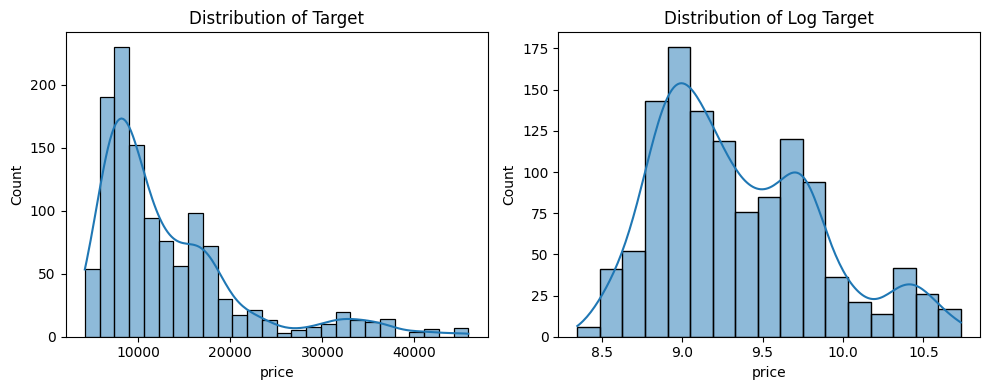

In [297]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(true_y, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Target")

sns.histplot(y, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Log Target")

plt.tight_layout()
plt.show()

Categorical and Numerical columns treatment

In [298]:
num_col = X.select_dtypes(include=np.number).columns.tolist()
cat_col = X.select_dtypes(include='object').columns.tolist()

In [299]:
for col in cat_col:
    print(col)
    print(X[col].unique())
    print('-' * 40)

CarName
['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 'buick skyhawk' 'buick ope

From the above values we have observed anomalies in the car names given.
we are going to seperate the brand name from the car name, drop car name column and then clean the anomalies.

In [300]:
X['brand'] = X['CarName'].str.split(' ', n = 1, expand = True)[0]
X.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,brand
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,alfa-romero
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,alfa-romero
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,alfa-romero
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,audi
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,audi


In [301]:
X = X.drop(columns=['CarName'])

In [302]:
# There are some misspelled names in the brand.

X['brand'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [303]:
# mis spelled names:
# alfa_romero: alfa_romeo
# maxda: mazda
# procshce: porsche
#toyouta: toyota
#vokswagen:volkswagen:vw

mis_spl = {
    'alfa-romero': 'alfa-romeo',
    'maxda': 'mazda',
    'procshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen':'volkswagen',
    'vw':'volkswagen',
}

X['brand'] = X['brand'].replace(mis_spl)
X['brand'].unique()

array(['alfa-romeo', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche', 'porcshce',
       'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'],
      dtype=object)

Proper encoding/mapping of values

In [304]:
X['fueltype'] = X['fueltype'].map({'gas': 0, 'diesel': 1})
X['aspiration'] = X['aspiration'].map({'std': 0, 'turbo': 1})
X['enginelocation'] = X['enginelocation'].map({'front': 0, 'rear': 1})

X['doornumber'] = X['doornumber'].map({'two': 2, 'four': 4})
X['cylindernumber'] = X['cylindernumber'].map({
    'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'eight': 8, 'twelve': 12})

In [305]:
cat_col = X.select_dtypes(include='object').columns.tolist()
num_col = X.select_dtypes(include=np.number).columns.tolist()

In [306]:
continuous = [
    'wheelbase','carlength','carwidth','carheight',
    'curbweight','enginesize','boreratio','stroke',
    'compressionratio','horsepower','peakrpm',
    'citympg','highwaympg'
]

binary = ['fueltype','aspiration','enginelocation']

ordinal = ['doornumber','cylindernumber','symboling']

nominal_cols = [
    'carbody',
    'drivewheel',
    'enginetype',
    'fuelsystem', 'brand'
]


Analysis

In [307]:
X[continuous].describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
count,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000
mean,98.666988,173.824116,65.862963,53.780614,2540.458091,125.783402,3.333726,3.249585,10.151228,102.838174,5120.887967,24.848963,30.432365
std,5.933994,11.990174,2.133770,2.384899,514.295644,41.043232,0.271573,0.313130,3.927543,39.924466,475.911167,6.228919,6.644243
min,86.390000,140.020000,60.180000,47.680000,1476.000000,58.000000,2.530000,2.060000,6.660000,45.000000,4113.000000,12.000000,15.000000
25%,94.590000,166.300000,64.090000,52.000000,2143.000000,97.000000,3.140000,3.100000,8.610000,71.000000,4800.000000,19.000000,25.000000
50%,96.820000,172.510000,65.440000,54.100000,2409.000000,113.000000,3.310000,3.280000,9.040000,93.000000,5168.000000,24.000000,30.000000
75%,101.490000,182.940000,66.680000,55.550000,2912.000000,142.000000,3.600000,3.410000,9.440000,116.000000,5486.000000,30.000000,34.000000
max,121.190000,208.680000,72.560000,60.060000,4107.000000,326.000000,3.980000,4.190000,23.230000,290.000000,6657.000000,49.000000,54.000000


Outlier treatment decision:
IQR-based analysis shows most continuous features have <5% outliers.
'stroke' (6.7%) and 'compressionratio' (~13%) have higher outlier rates.

In [308]:
outlier_summary = {}

for col in continuous:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_summary[col] = round((outliers / len(X)) * 100, 2)

outlier_summary

{'wheelbase': np.float64(4.4),
 'carlength': np.float64(0.41),
 'carwidth': np.float64(4.56),
 'carheight': np.float64(0.0),
 'curbweight': np.float64(0.83),
 'enginesize': np.float64(3.65),
 'boreratio': np.float64(0.0),
 'stroke': np.float64(6.72),
 'compressionratio': np.float64(13.44),
 'horsepower': np.float64(4.4),
 'peakrpm': np.float64(0.91),
 'citympg': np.float64(0.41),
 'highwaympg': np.float64(0.75)}

CompressionRatio is heavily skewed but meaningfully

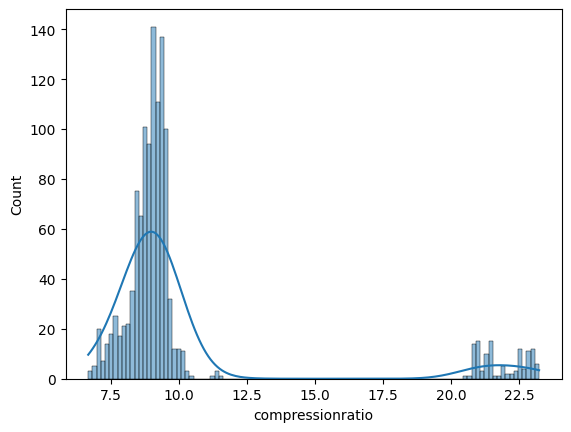

In [309]:
sns.histplot(X['compressionratio'], kde=True)
plt.show()

Explanation for high compression ratio

<Axes: xlabel='fueltype', ylabel='compressionratio'>

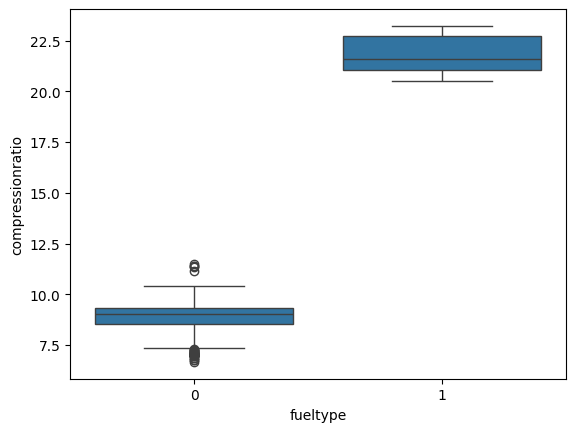

In [310]:
sns.boxplot(x='fueltype', y='compressionratio', data=X)

The following features show strong positive correlation with each other:

* wheelbase

* carlength

* carwidth

* curbweight

* enginesize

* horsepower

This indicates that larger cars tend to be heavier and have bigger engines with higher horsepower.

citympg and highwaympg are highly correlated with each other.
This suggests potential redundancy in linear modelinng

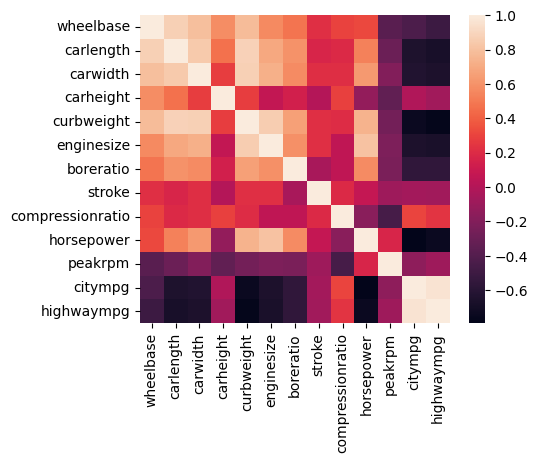

In [311]:
plt.figure(figsize=(5,4))
sns.heatmap(X[continuous].corr())
plt.show()

As engine size increase, price also increases

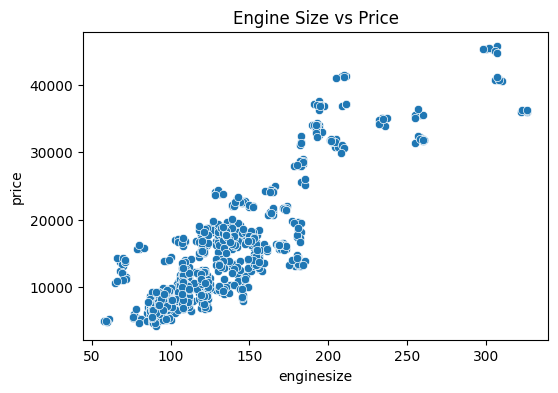

In [312]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='enginesize', y='price', data=df)
plt.title("Engine Size vs Price")
plt.show()

Engine type does affect price, but not as strongly as engine size.

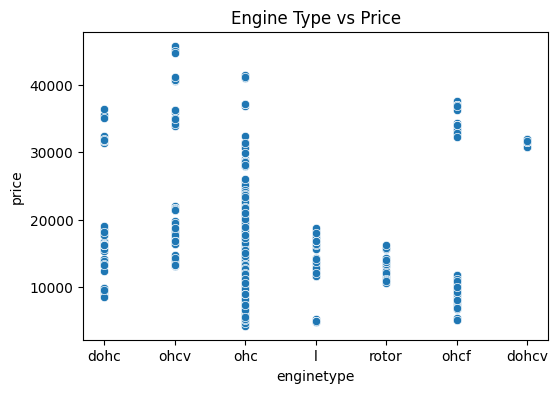

In [313]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='enginetype', y='price', data=df)
plt.title("Engine Type vs Price")
plt.show()

* Most economical - hatchback
* Most expensive - Hardtop

<Axes: xlabel='carbody', ylabel='price'>

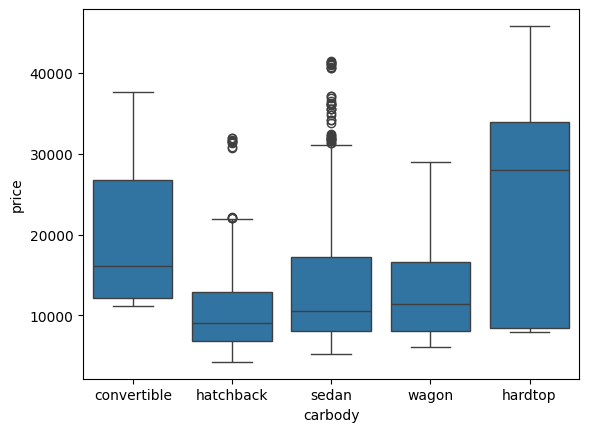

In [314]:
sns.boxplot(x='carbody', y='price', data=df)

Pipeline

In [315]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous),
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
        ("bin", "passthrough", binary),
        ("ord", "passthrough", ordinal)
    ]
)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

Model 1 - Ridge

In [316]:
from sklearn.linear_model import RidgeCV
import numpy as np

alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

print("Best alpha:", ridge.alpha_)

Best alpha: 0.49417133613238334


In [317]:
from sklearn.metrics import r2_score, mean_squared_error,mean_squared_log_error
import numpy as np

y_pred_log = ridge.predict(X_test)

print("R2 (log):", r2_score(y_test, y_pred_log))

# Converting back from log scale
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

print("RMSE (original):",
      np.sqrt(mean_squared_error(y_test_original, y_pred)))

rmsle = np.sqrt(mean_squared_log_error(y_test_original, y_pred))
print("RMSLE:", rmsle)

R2 (log): 0.9506712333265598
RMSE (original): 1403.4245090537781
RMSLE: 0.10276384172791257


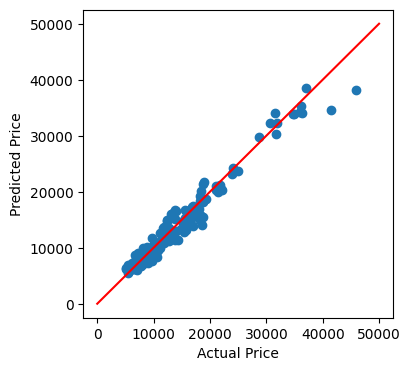

In [318]:
plt.figure(figsize=(4,4))
plt.scatter(y_test_original, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.plot([0,50000],[0,50000], color='red')

In [319]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
coef_df.head(10)

,Feature,Coefficient
34,cat__brand_bmw,0.507653
48,cat__brand_porsche,0.363672
47,cat__brand_porcshce,0.323836
57,bin__enginelocation,0.294639
50,cat__brand_saab,0.256494
4,num__curbweight,0.229625
32,cat__brand_alfa-romeo,0.206937
24,cat__enginetype_rotor,0.186244
33,cat__brand_audi,0.185997
20,cat__enginetype_l,0.167574


Model 2 - Linear Regression

In [322]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_lr = X_train_df.drop(columns=['highwaympg'])
X_test_lr = X_test_df.drop(columns=['highwaympg'])

X_train_lr = preprocessor_lr.fit_transform(X_train_lr)
X_test_lr = preprocessor_lr.transform(X_test_lr)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_log_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)

print("Linear Regression (without highwaympg)")
print("R2 (log):", r2_score(y_test_lr, y_pred_lr))
print("RMSLE:", np.sqrt(mean_squared_log_error(
    np.expm1(y_test_lr), np.expm1(y_pred_lr)
)))

Linear Regression (without highwaympg)
R2 (log): 0.9508235297718016
RMSLE: 0.1026050837928299


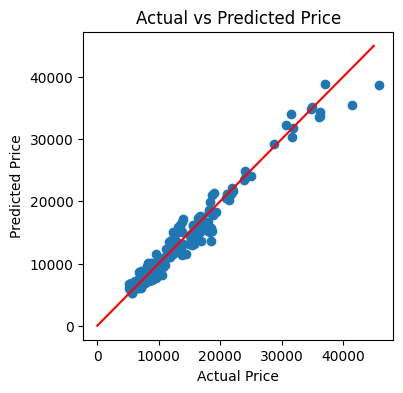

In [323]:
plt.figure(figsize=(4,4))
plt.scatter(np.expm1(y_test_lr), np.expm1(y_pred_lr))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot([0,45000],[0,45000], color='red')
plt.show()

Model 3- LASSO

In [324]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_log_error, mean_squared_error
import numpy as np
import pandas as pd


alphas = np.logspace(-4, 1, 50)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train, y_train)
print("Best alpha:", lasso.alpha_)

y_pred_lasso = lasso.predict(X_test)
print("\nLasso Regression Results")
print("R2 (log):", r2_score(y_test, y_pred_lasso))

rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lasso)))
print("RMSE (original):", rmse)

rmsle = np.sqrt(mean_squared_log_error(
    np.expm1(y_test), np.expm1(y_pred_lasso)
))
print("RMSLE:", rmsle)

coef_lasso = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso.coef_
})

coef_lasso = coef_lasso.sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 10 Important Features")
print(coef_lasso.head(10))

Best alpha: 0.0001

Lasso Regression Results
R2 (log): 0.9505591027855094
RMSE (original): 1404.9849475550686
RMSLE: 0.10288057305013862

Top 10 Important Features
                   Feature  Coefficient
34          cat__brand_bmw     0.532460
48      cat__brand_porsche     0.407643
57     bin__enginelocation     0.406626
47     cat__brand_porcshce     0.383915
50         cat__brand_saab     0.264968
45      cat__brand_peugeot    -0.261773
14  cat__carbody_hatchback    -0.242466
4          num__curbweight     0.233235
16      cat__carbody_wagon    -0.220850
32   cat__brand_alfa-romeo     0.206232


In [325]:
coef_lasso[coef_lasso["Coefficient"] == 0]

,Feature,Coefficient
26,cat__fuelsystem_4bbl,0.0
31,cat__fuelsystem_spfi,-0.0
51,cat__brand_subaru,-0.0


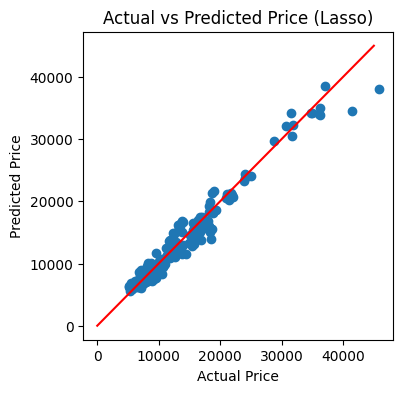

In [326]:
plt.figure(figsize=(4,4))

plt.scatter(np.expm1(y_test_lr), np.expm1(y_pred_lasso))

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Lasso)")

plt.plot([0,45000], [0,45000], color='red')

plt.show()